Import Libraries



In [ ]:
!pip -q install scikit-learn

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


Load IMDB Dataset

In [ ]:
max_features = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=max_features
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


Pad the sequence

In [ ]:
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (25000, 200)
Testing data shape: (25000, 200)


Build the Models

In [ ]:
def build_model(model_type):

    model = Sequential()

    model.add(
        Embedding(
            input_dim=max_features,
            output_dim=128
        )
    )

    if model_type == "RNN":
        model.add(SimpleRNN(64))

    elif model_type == "LSTM":
        model.add(LSTM(64))

    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

Train and Evaluate All three Models

In [ ]:
results = []

for model_type in ["RNN", "LSTM", "GRU"]:

    print("\n====================")
    print(model_type)
    print("====================")

    model = build_model(model_type)

    model.fit(
        x_train,
        y_train,
        epochs=3,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    # Prediction
    prediction = model.predict(x_test)

    prediction = (prediction > 0.5).astype(int).ravel()

    # Metrics
    accuracy = accuracy_score(y_test, prediction)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        prediction,
        average='binary'
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, prediction)

    print("\nConfusion Matrix:")
    print(cm)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    results.append([
        model_type,
        accuracy,
        precision,
        recall,
        f1
    ])


RNN
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 170ms/step - accuracy: 0.7412 - loss: 0.5176 - val_accuracy: 0.7856 - val_loss: 0.4661
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - accuracy: 0.8849 - loss: 0.2847 - val_accuracy: 0.8438 - val_loss: 0.3827
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 143ms/step - accuracy: 0.9440 - loss: 0.1547 - val_accuracy: 0.8466 - val_loss: 0.4148
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step

Confusion Matrix:
[[10322  2178]
 [ 1686 10814]]
Accuracy : 0.84544
Precision: 0.8323583743842364
Recall   : 0.86512
F1 Score : 0.8484230346775459

LSTM
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 423ms/step - accuracy: 0.7914 - loss: 0.4489 - val_accuracy: 0.8560 - val_loss: 0.3422
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 65s 411ms/step - accuracy: 0.9032 - loss: 0.2512 - val_accuracy: 0.8736 - val_loss: 0.3055
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 65s 412ms/step - accuracy: 0.9336 - loss: 0.1848 - val_accuracy: 0.8550 - val_loss: 0.3859
782/782 ━━━━━━━━━━

Comparision Table

In [ ]:
df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print(df)

  Model  Accuracy  Precision   Recall  F1 Score
0   RNN   0.84544   0.832358  0.86512  0.848423
1  LSTM   0.85668   0.815959  0.92112  0.865356
2   GRU   0.84224   0.885336  0.78632  0.832896


Plot Accuracy Comparision

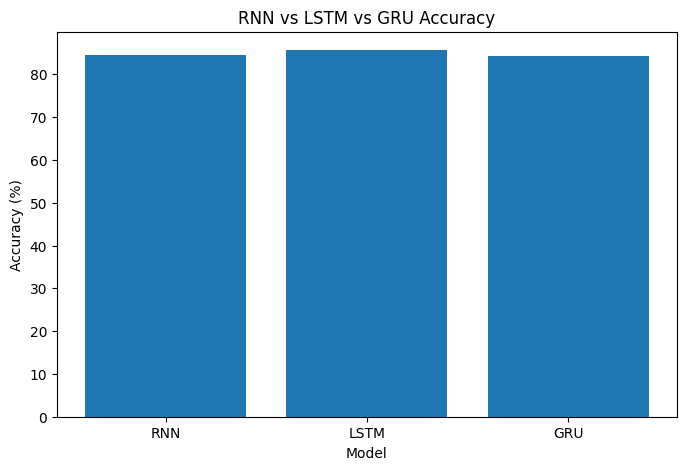

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    df['Model'],
    df['Accuracy'] * 100
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("RNN vs LSTM vs GRU Accuracy")

plt.show()

Compare All Metrices

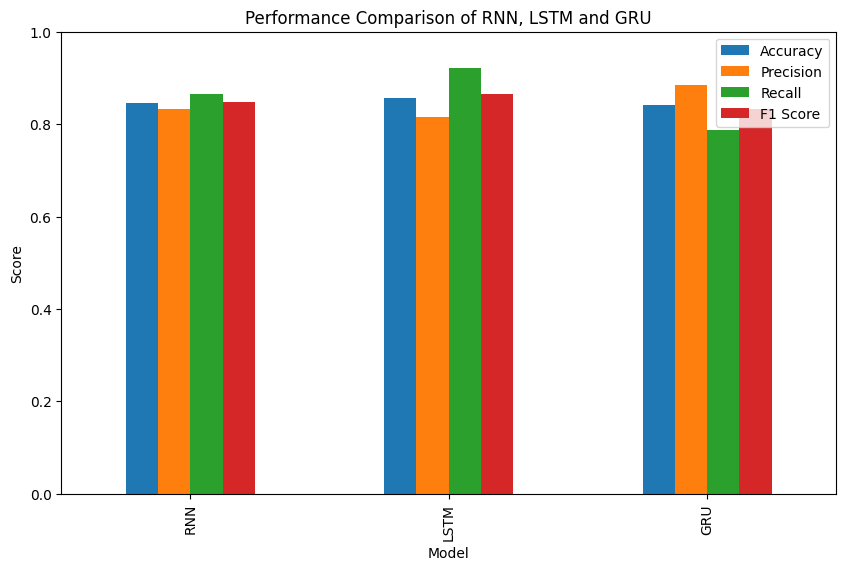

In [ ]:
df.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Performance Comparison of RNN, LSTM and GRU")
plt.ylim(0, 1)
plt.legend()
plt.show()

Find the best Model

In [ ]:
best_model = df.loc[
    df['Accuracy'].idxmax(),
    'Model'
]

best_accuracy = df['Accuracy'].max()

print("Best Model:", best_model)
print("Best Accuracy:", round(best_accuracy * 100, 2), "%")

Best Model: LSTM
Best Accuracy: 85.67 %
